# Wait-Time Pressure Simulation

This notebook simulates how adding a new attraction could reduce guest experience pressure at Disney Animal Kingdom by redistributing a percentage of high-wait demand away from the park's highest-pressure attractions.

The goal is not to predict exact future wait times, but to model possible operational impact under different demand redistribution scenarios.

## 1. Load Cleaned Dataset

In this section, I load the cleaned Disney Animal Kingdom wait-time dataset created in the first notebook. This dataset includes attraction names, cleaned posted wait times, time-based fields, and high-wait indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

Saving animal_kingdom_wait_times_cleaned.csv to animal_kingdom_wait_times_cleaned.csv


In [2]:
wait_times = pd.read_csv("animal_kingdom_wait_times_cleaned.csv")

wait_times.head()

,date,datetime,posted_wait_minutes,actual_wait_minutes,source_file,attraction_name,posted_wait_invalid,actual_wait_invalid,posted_wait_minutes_clean,actual_wait_minutes_clean,year,month,month_name,day_of_week,hour_of_day,date_only,wait_time_gap,is_high_wait,wait_time_category
0,2012-01-01,2012-01-01 10:28:00,0.0,NaN,AK01.csv,Kilimanjaro Safaris,False,False,0.0,NaN,2012,1,January,Sunday,10,2012-01-01,NaN,0,0-15 min
1,2012-01-01,2012-01-01 11:48:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris,False,False,5.0,NaN,2012,1,January,Sunday,11,2012-01-01,NaN,0,0-15 min
2,2012-01-01,2012-01-01 14:21:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris,False,False,5.0,NaN,2012,1,January,Sunday,14,2012-01-01,NaN,0,0-15 min
3,2012-01-01,2012-01-01 16:40:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris,False,False,5.0,NaN,2012,1,January,Sunday,16,2012-01-01,NaN,0,0-15 min
4,2012-01-01,2012-01-01 17:39:00,0.0,NaN,AK01.csv,Kilimanjaro Safaris,False,False,0.0,NaN,2012,1,January,Sunday,17,2012-01-01,NaN,0,0-15 min


## 2. Define Baseline Wait-Time Pressure

This section establishes the baseline level of guest experience pressure before any simulated operational changes. A high-wait record is defined as a valid posted wait-time record of 45 minutes or more.

In [3]:
baseline_valid_records = wait_times["posted_wait_minutes_clean"].notna().sum()
baseline_high_wait_records = wait_times["is_high_wait"].sum()
baseline_high_wait_rate = baseline_high_wait_records / baseline_valid_records * 100

baseline_summary = pd.DataFrame({
    "Metric": [
        "Valid Posted Wait Records",
        "High-Wait Records",
        "High-Wait Rate (%)"
    ],
    "Baseline Value": [
        baseline_valid_records,
        baseline_high_wait_records,
        round(baseline_high_wait_rate, 2)
    ]
})

baseline_summary

,Metric,Baseline Value
0,Valid Posted Wait Records,1758656.00
1,High-Wait Records,388915.00
2,High-Wait Rate (%),22.11


### Interpretation

The baseline analysis shows the starting level of wait-time pressure before any simulated operational changes. The cleaned dataset contains over 1.75 million valid posted wait-time records, with 388,915 records classified as high-wait observations of 45 minutes or more.

This baseline will be used to compare the estimated impact of adding a new attraction that redistributes demand away from high-pressure attractions.

## 3. Identify Target Attractions for Demand Redistribution

This section identifies the attractions that contributed the greatest wait-time pressure. The simulation assumes that a new attraction would primarily draw demand away from the highest-pressure attractions rather than evenly affecting the entire park.

In [4]:
target_attraction_summary = (
    wait_times
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("attraction_name")
    .agg(
        valid_posted_wait_records=("posted_wait_minutes_clean", "count"),
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        high_wait_records=("is_high_wait", "sum"),
        high_wait_rate=("is_high_wait", "mean")
    )
    .reset_index()
)

target_attraction_summary["avg_posted_wait"] = target_attraction_summary["avg_posted_wait"].round(2)
target_attraction_summary["high_wait_rate_pct"] = (target_attraction_summary["high_wait_rate"] * 100).round(2)

target_attraction_summary = target_attraction_summary.drop(columns=["high_wait_rate"])

target_attraction_summary.sort_values("high_wait_records", ascending=False)

,attraction_name,valid_posted_wait_records,avg_posted_wait,high_wait_records,high_wait_rate_pct
1,Avatar Flight of Passage,78581,136.03,77949,99.20
2,DINOSAUR,217285,34.81,72908,33.55
9,Na'vi River Journey,76758,75.29,65325,85.11
3,Expedition Everest,224460,31.03,56892,25.35
7,Kali River Rapids,183719,33.50,55798,30.37
10,Primeval Whirl,204465,24.86,31320,15.32
0,Adventurers Outpost,147933,23.84,14795,10.00
6,It's Tough to Be a Bug,214691,19.89,12491,5.82
8,Kilimanjaro Safaris,213522,9.77,1129,0.53
5,Finding Nemo - The Musical,2921,18.37,192,6.57


### Target Attraction Selection

For this simulation, the new attraction is assumed to draw demand away from the top guest experience pressure points. These attractions are selected based on a combination of high-wait record volume, average posted wait time, and high-wait rate.

The simulation focuses on the following attractions:

- Avatar Flight of Passage
- Na'vi River Journey
- DINOSAUR
- Expedition Everest
- Kali River Rapids

These attractions contributed a large share of the long-wait observations in the dataset and represent the most logical targets for demand redistribution.

In [5]:
target_attractions = [
    "Avatar Flight of Passage",
    "Na'vi River Journey",
    "DINOSAUR",
    "Expedition Everest",
    "Kali River Rapids"
]

target_waits = wait_times[
    wait_times["attraction_name"].isin(target_attractions)
].copy()

target_waits.shape

(840923, 19)

## 4. Build New Ride Simulation Scenarios

This section simulates how adding a new attraction could reduce long-wait pressure by redistributing a percentage of high-wait demand away from the highest-pressure attractions.

The model tests four demand redistribution scenarios:

- 5% reduction in high-wait records among target attractions
- 10% reduction in high-wait records among target attractions
- 15% reduction in high-wait records among target attractions
- 20% reduction in high-wait records among target attractions

These scenarios are not predictions. They are planning estimates that show how different levels of demand redistribution could affect guest experience pressure.

In [6]:
scenario_rates = [0.05, 0.10, 0.15, 0.20]

target_high_wait_records = target_waits["is_high_wait"].sum()

simulation_results = []

for rate in scenario_rates:
    reduced_high_wait_records = target_high_wait_records * rate
    new_total_high_wait_records = baseline_high_wait_records - reduced_high_wait_records
    new_high_wait_rate = new_total_high_wait_records / baseline_valid_records * 100

    simulation_results.append({
        "scenario": f"{int(rate * 100)}% demand redistribution",
        "redistribution_rate": rate,
        "estimated_reduced_high_wait_records": round(reduced_high_wait_records),
        "new_total_high_wait_records": round(new_total_high_wait_records),
        "new_high_wait_rate_pct": round(new_high_wait_rate, 2),
        "high_wait_rate_reduction_points": round(baseline_high_wait_rate - new_high_wait_rate, 2)
    })

simulation_results_df = pd.DataFrame(simulation_results)

simulation_results_df

,scenario,redistribution_rate,estimated_reduced_high_wait_records,new_total_high_wait_records,new_high_wait_rate_pct,high_wait_rate_reduction_points
0,5% demand redistribution,0.05,16444,372471,21.18,0.94
1,10% demand redistribution,0.10,32887,356028,20.24,1.87
2,15% demand redistribution,0.15,49331,339584,19.31,2.81
3,20% demand redistribution,0.20,65774,323141,18.37,3.74


### Interpretation

The simulation results estimate how overall high-wait pressure could change if a new attraction redistributed demand away from the highest-pressure attractions.

Under the 5% redistribution scenario, the model estimates a reduction of 16,444 high-wait records, lowering the overall high-wait rate from 22.11% to 21.18%.

Under the 10% redistribution scenario, the model estimates a reduction of 32,887 high-wait records, lowering the overall high-wait rate to 20.24%. This provides a useful moderate-impact planning benchmark.

The 15% and 20% scenarios show larger potential reductions, with the 20% scenario reducing estimated high-wait records by 65,774 and lowering the overall high-wait rate to 18.37%.

These results suggest that even modest demand redistribution away from the park's highest-pressure attractions could meaningfully reduce long-wait exposure across the historical dataset.

## 5. Attraction-Level Scenario Impact

This section estimates how each target attraction could be affected under different demand redistribution scenarios. The goal is to show which attractions would benefit most from a new ride absorbing some high-wait demand.

In [7]:
attraction_impact = (
    target_waits
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("attraction_name")
    .agg(
        baseline_high_wait_records=("is_high_wait", "sum"),
        baseline_valid_records=("posted_wait_minutes_clean", "count"),
        avg_posted_wait=("posted_wait_minutes_clean", "mean")
    )
    .reset_index()
)

attraction_impact["baseline_high_wait_rate_pct"] = (
    attraction_impact["baseline_high_wait_records"] /
    attraction_impact["baseline_valid_records"] * 100
).round(2)

attraction_impact["avg_posted_wait"] = attraction_impact["avg_posted_wait"].round(2)

attraction_impact

,attraction_name,baseline_high_wait_records,baseline_valid_records,avg_posted_wait,baseline_high_wait_rate_pct
0,Avatar Flight of Passage,77949,78581,136.03,99.20
1,DINOSAUR,72908,217285,34.81,33.55
2,Expedition Everest,56892,224460,31.03,25.35
3,Kali River Rapids,55798,183719,33.50,30.37
4,Na'vi River Journey,65325,76758,75.29,85.11


In [8]:
# Now lets simulate the 10% scenario, which is usually a good “moderate impact”

moderate_rate = 0.10

attraction_impact_10pct = attraction_impact.copy()

attraction_impact_10pct["estimated_reduced_high_wait_records"] = (
    attraction_impact_10pct["baseline_high_wait_records"] * moderate_rate
).round()

attraction_impact_10pct["simulated_high_wait_records"] = (
    attraction_impact_10pct["baseline_high_wait_records"] -
    attraction_impact_10pct["estimated_reduced_high_wait_records"]
).round()

attraction_impact_10pct["simulated_high_wait_rate_pct"] = (
    attraction_impact_10pct["simulated_high_wait_records"] /
    attraction_impact_10pct["baseline_valid_records"] * 100
).round(2)

attraction_impact_10pct.sort_values(
    "estimated_reduced_high_wait_records",
    ascending=False
)

,attraction_name,baseline_high_wait_records,baseline_valid_records,avg_posted_wait,baseline_high_wait_rate_pct,estimated_reduced_high_wait_records,simulated_high_wait_records,simulated_high_wait_rate_pct
0,Avatar Flight of Passage,77949,78581,136.03,99.20,7795.0,70154.0,89.28
1,DINOSAUR,72908,217285,34.81,33.55,7291.0,65617.0,30.20
4,Na'vi River Journey,65325,76758,75.29,85.11,6532.0,58793.0,76.60
2,Expedition Everest,56892,224460,31.03,25.35,5689.0,51203.0,22.81
3,Kali River Rapids,55798,183719,33.50,30.37,5580.0,50218.0,27.33


### Interpretation

The attraction-level scenario impact shows how a 10% demand redistribution assumption could reduce high-wait exposure across the selected target attractions.

Avatar Flight of Passage shows the largest estimated reduction, with approximately 7,795 fewer high-wait records under the 10% scenario. DINOSAUR follows with an estimated reduction of 7,291 high-wait records, while Na'vi River Journey shows an estimated reduction of 6,532 high-wait records.

Expedition Everest and Kali River Rapids also show meaningful estimated reductions, with approximately 5,689 and 5,580 fewer high-wait records respectively.

The simulated high-wait rates decrease for each attraction because the model assumes a proportional reduction in high-wait records. Avatar Flight of Passage remains a major pressure point even after the simulated reduction, with a simulated high-wait rate of 89.28%. Na'vi River Journey also remains elevated at 76.60%.

This suggests that a new attraction could reduce long-wait exposure, but the highest-demand attractions would likely continue to require operational attention even after demand redistribution.

## 6. Visualize Estimated Impact

This section visualizes the estimated impact of each demand redistribution scenario. The charts compare baseline high-wait pressure against simulated outcomes.

### 6.1 Simulated High-Wait Records by Scenario

This chart compares the estimated total number of high-wait records after each demand redistribution scenario. The baseline high-wait record count is included as a reference point so the simulated reductions can be compared against the original level of wait-time pressure.

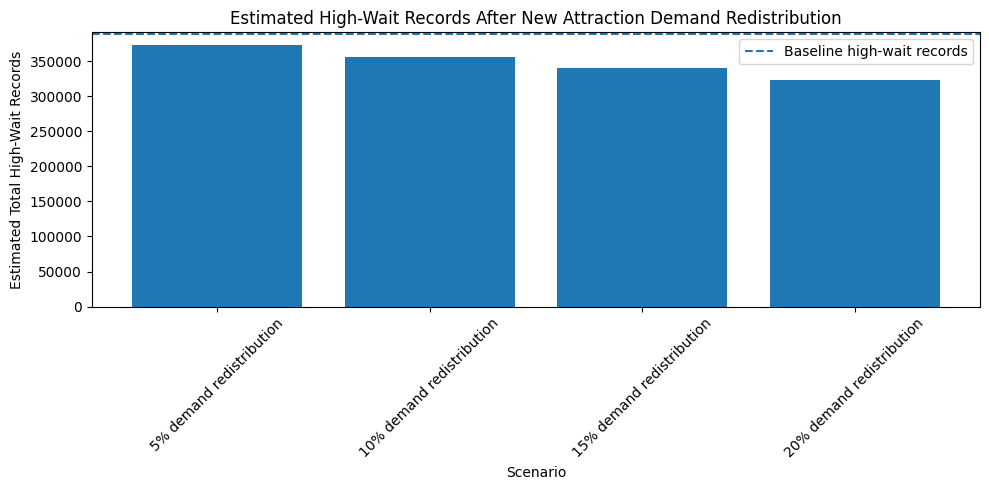

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(
    simulation_results_df["scenario"],
    simulation_results_df["new_total_high_wait_records"]
)

plt.axhline(
    y=baseline_high_wait_records,
    linestyle="--",
    label="Baseline high-wait records"
)

plt.xlabel("Scenario")
plt.ylabel("Estimated Total High-Wait Records")
plt.title("Estimated High-Wait Records After New Attraction Demand Redistribution")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("simulated_high_wait_records_by_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The scenario comparison chart shows that higher levels of demand redistribution are associated with lower estimated high-wait record totals. The baseline line represents the original number of high-wait records before the simulated new attraction impact.

The 5% redistribution scenario produces a modest reduction from the baseline, while the 10%, 15%, and 20% scenarios show increasingly larger reductions. The 20% scenario produces the largest estimated decrease, lowering total high-wait records from 388,915 to approximately 323,141.

This suggests that a new attraction could meaningfully reduce long-wait exposure if it successfully redistributed demand away from the highest-pressure attractions. However, the chart also shows that modest redistribution would reduce pressure gradually rather than eliminate high-wait conditions entirely.

### 6.2 Estimated Reduction in High-Wait Records by Scenario

This chart shows the estimated number of high-wait records reduced under each demand redistribution scenario. It focuses directly on the potential improvement created by each scenario.

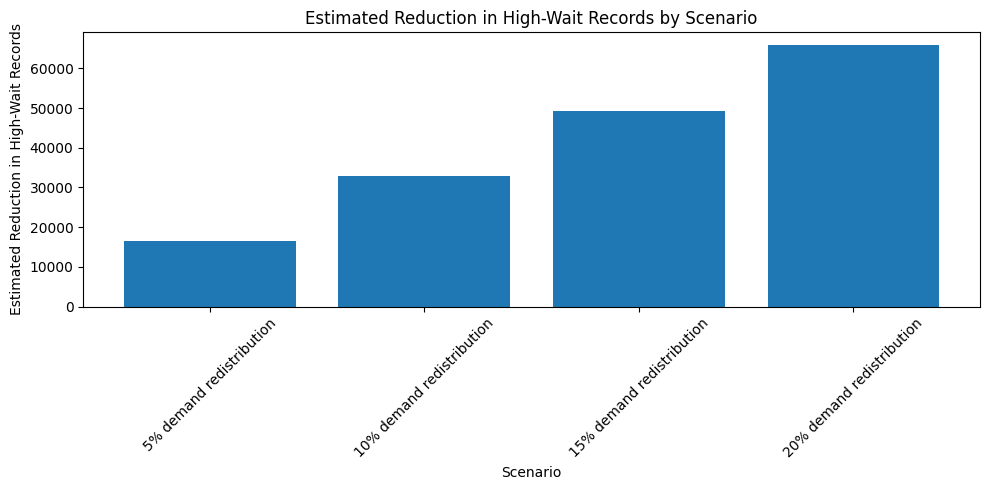

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(
    simulation_results_df["scenario"],
    simulation_results_df["estimated_reduced_high_wait_records"]
)

plt.xlabel("Scenario")
plt.ylabel("Estimated Reduction in High-Wait Records")
plt.title("Estimated Reduction in High-Wait Records by Scenario")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("estimated_reduction_by_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The estimated reduction chart shows a clear increase in impact as the redistribution assumption rises from 5% to 20%. Under the 5% scenario, the model estimates a reduction of approximately 16,444 high-wait records. Under the 10% moderate-impact scenario, the estimated reduction increases to approximately 32,887 high-wait records.

The 15% and 20% scenarios show larger estimated reductions of approximately 49,331 and 65,774 high-wait records. This pattern shows that the simulated impact scales directly with the amount of demand redistributed away from the highest-pressure attractions.

The 10% scenario remains a useful planning benchmark because it shows a meaningful reduction in long-wait exposure without assuming an overly aggressive shift in guest demand.

### 6.3 Attraction-Level Impact Under 10% Redistribution Scenario

This chart shows the estimated reduction in high-wait records for each target attraction under the 10% demand redistribution scenario. The goal is to identify which attractions could benefit most from a new attraction absorbing some high-wait demand.

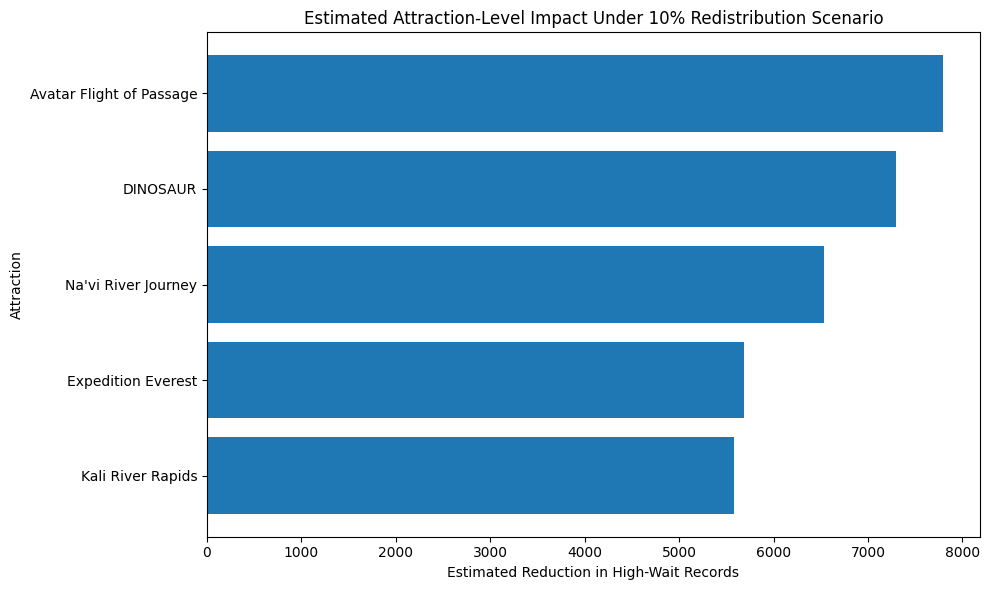

In [11]:
attraction_impact_10pct_chart = attraction_impact_10pct.sort_values(
    "estimated_reduced_high_wait_records",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    attraction_impact_10pct_chart["attraction_name"],
    attraction_impact_10pct_chart["estimated_reduced_high_wait_records"]
)

plt.xlabel("Estimated Reduction in High-Wait Records")
plt.ylabel("Attraction")
plt.title("Estimated Attraction-Level Impact Under 10% Redistribution Scenario")
plt.tight_layout()

plt.savefig("attraction_level_impact_10pct_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The attraction-level impact chart shows that Avatar Flight of Passage would see the largest estimated reduction under the 10% redistribution scenario, with approximately 7,795 fewer high-wait records. DINOSAUR would see the second-largest estimated reduction at approximately 7,291 high-wait records, followed by Na'vi River Journey at approximately 6,532.

Expedition Everest and Kali River Rapids also show meaningful estimated reductions, with each attraction reducing high-wait exposure by more than 5,500 records under the 10% scenario.

This reinforces the idea that the greatest operational benefit would come from reducing pressure on a small group of high-demand attractions. However, because Avatar Flight of Passage and Na'vi River Journey still have very high simulated high-wait rates after redistribution, these attractions would likely remain important guest experience pressure points even if a new attraction helped spread demand.

## 7. Key Findings and Business Recommendations

This section summarizes the main findings from the wait-time pressure simulation and translates the results into operational recommendations. The simulation is intended to estimate possible changes in high-wait exposure under different demand redistribution assumptions, not to predict exact future guest behavior.

### 7.1 Key Findings

1. **A new attraction could meaningfully reduce long-wait exposure.**  
   The simulation shows that even modest demand redistribution away from the highest-pressure attractions could reduce the total number of high-wait records in the historical dataset.

2. **The 10% redistribution scenario provides a useful planning benchmark.**  
   Under the 10% scenario, the model estimated a reduction of approximately 32,887 high-wait records. This lowered the overall high-wait rate from 22.11% to 20.24%.

3. **The largest attraction-level reductions came from the biggest pressure points.**  
   Avatar Flight of Passage had the largest estimated reduction under the 10% scenario, followed by DINOSAUR, Na'vi River Journey, Expedition Everest, and Kali River Rapids.

4. **A new attraction would help, but it would not eliminate high-wait pressure.**  
   Even after the simulated 10% redistribution, Avatar Flight of Passage and Na'vi River Journey would remain major guest experience pressure points. This suggests that a new attraction should be paired with continued queue management and guest flow strategies.

5. **Scenario modeling helps connect analytics to operational planning.**  
   This notebook demonstrates how historical wait-time data can be used to evaluate possible operational improvements and support strategic decision-making.

### 7.2 Business Recommendations

1. **Prioritize new attraction planning around high-pressure demand areas.**  
   A new attraction would likely have the greatest operational impact if it helped absorb demand from the attractions with the highest long-wait volume.

2. **Use moderate scenarios for planning conversations.**  
   The 10% redistribution scenario is a useful benchmark because it shows meaningful improvement without assuming an unrealistic shift in guest behavior.

3. **Pair new attractions with guest flow strategies.**  
   A new ride alone may not fully solve long-wait pressure. Operational teams could also use app messaging, signage, itinerary recommendations, and crowd-flow planning to help distribute demand.

4. **Continue monitoring high-wait records as a guest experience KPI.**  
   High-wait record volume can help identify where guests are most likely to experience long waits and where operational improvements may have the strongest impact.

5. **Use scenario models to compare future investment options.**  
   The same simulation approach could be adapted to compare multiple ride concepts, capacity assumptions, or demand redistribution strategies.

### 7.3 Simulation Summary

This notebook modeled how adding a new attraction could reduce high-wait pressure at Disney Animal Kingdom by redistributing demand away from the park's highest-pressure attractions.

The simulation showed that even modest reductions in high-wait demand among key attractions could lower total long-wait exposure across the park. Under the 10% redistribution scenario, the model estimated approximately 32,887 fewer high-wait records and reduced the overall high-wait rate from 22.11% to 20.24%.

While this model is not intended to predict exact future wait times, it provides a practical framework for evaluating how new attraction investments could support guest experience and operational planning.